# Day 77: Image Classification with Transfer Learning
This notebook demonstrates a complete portfolio-ready image classification project using transfer learning (VGG16), data augmentation, and fine-tuning on the built-in `tf_flowers` dataset.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import numpy as np

## Load TensorFlow Flowers Dataset
We will use the built-in `tf_flowers` dataset with 5 classes: Daisy, Dandelion, Roses, Sunflowers, Tulips.

In [3]:
import tensorflow_datasets as tfds

# Load dataset
(dataset_train, dataset_val), info = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True
)

NUM_CLASSES = info.features['label'].num_classes
IMG_SIZE = 224
BATCH_SIZE = 16

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.C7691Z_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


## Data Augmentation
We apply rotation, flipping, zoom, and color shift to improve generalization.

In [4]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0
    return image, label

# Apply preprocessing
dataset_train = dataset_train.map(preprocess).shuffle(1000).batch(BATCH_SIZE)
dataset_val = dataset_val.map(preprocess).batch(BATCH_SIZE)

# Data augmentation layers
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.1)
])

## Load VGG16 Pretrained Model
We remove the top layers and freeze the base for feature extraction.

In [5]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False  # Freeze base

# Build the model
model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')  # multi-class
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

## Train classifier on top layers first (Feature Extraction)
We train only the new classifier layers initially.

In [6]:
EPOCHS_FE = 5

history_fe = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=EPOCHS_FE
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 106ms/step - accuracy: 0.3871 - loss: 1.4837 - val_accuracy: 0.7071 - val_loss: 0.9244
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - accuracy: 0.6418 - loss: 0.9714 - val_accuracy: 0.7411 - val_loss: 0.7368
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 0.7062 - loss: 0.8198 - val_accuracy: 0.7752 - val_loss: 0.6577
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 105ms/step - accuracy: 0.7084 - loss: 0.7570 - val_accuracy: 0.7943 - val_loss: 0.6055
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.7230 - loss: 0.7288 - val_accuracy: 0.7793 - val_loss: 0.6009


## Fine-Tuning Top Layers
Unfreeze some of the base model layers for better performance.

In [7]:
# Unfreeze last few layers of VGG16
base_model.trainable = True
for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with small learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FT = 5

history_ft = model.fit(
    dataset_train,
    validation_data=dataset_val,
    epochs=EPOCHS_FT
)

Epoch 1/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - accuracy: 0.7635 - loss: 0.6512 - val_accuracy: 0.8433 - val_loss: 0.4459
Epoch 2/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 26s 140ms/step - accuracy: 0.8225 - loss: 0.4988 - val_accuracy: 0.8610 - val_loss: 0.3926
Epoch 3/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 27s 143ms/step - accuracy: 0.8443 - loss: 0.4413 - val_accuracy: 0.8787 - val_loss: 0.3291
Epoch 4/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 27s 142ms/step - accuracy: 0.8674 - loss: 0.3703 - val_accuracy: 0.8774 - val_loss: 0.3118
Epoch 5/5
184/184 ━━━━━━━━━━━━━━━━━━━━ 27s 140ms/step - accuracy: 0.8805 - loss: 0.3223 - val_accuracy: 0.8815 - val_loss: 0.2984


## Plot Training & Validation Accuracy

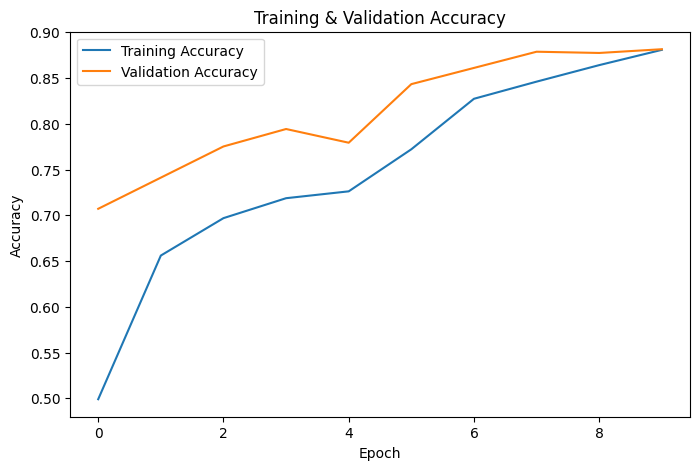

In [8]:
acc = history_fe.history['accuracy'] + history_ft.history['accuracy']
val_acc = history_fe.history['val_accuracy'] + history_ft.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
model.save("day77_flowers_classifier.keras")

## Make Predictions on Sample Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step


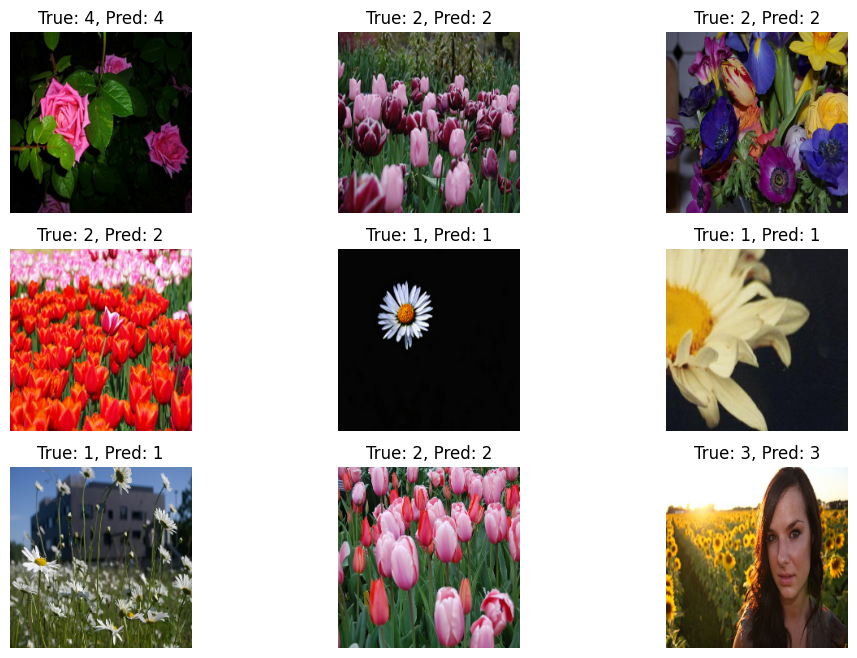

In [9]:
import matplotlib.pyplot as plt

for image_batch, label_batch in dataset_val.take(1):
    predictions = model.predict(image_batch)
    predicted_labels = np.argmax(predictions, axis=1)

    plt.figure(figsize=(12,8))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image_batch[i])
        plt.title(f"True: {label_batch[i].numpy()}, Pred: {predicted_labels[i]}")
        plt.axis('off')
    plt.show()